In [1]:
from pathlib import Path

from maite_datasets.object_detection import SkySeaLand

# Downloads to ./data/skysealand on first run (~262 MB), then writes the datamaite-format
# export beside it. A re-run reuses the export instead of rebuilding it.
SkySeaLand(root="./data", image_set="base", download=True, as_datamaite=True)

data_path = Path("./data/skysealand_datamaite_base")

/builds/jatic/aria/dataeval-flow/.nox/docs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from dataeval.config import set_max_processes

from dataeval_flow.config import (
    BoVWExtractorConfig,
    CocoDatasetConfig,
    DataCleaningTaskConfig,
    DataCleaningWorkflowConfig,
    PipelineConfig,
    SourceConfig,
    ViewConfig,
    ViewOperation,
)
from dataeval_flow.workflow import run_task
from dataeval_flow.workflows.cleaning.params import DataCleaningHealthThresholds

# Each worker decodes its own images, so peak memory is roughly workers x batch x image
# size. Four keeps a 300-frame pass comfortable on a 16 GB machine; raise it if you have
# the headroom.
set_max_processes(4)

advisory_workflow = DataCleaningWorkflowConfig(
    name="skysealand_advisory_clean",
    mode="advisory",
    outlier_method="adaptive",  # Use adaptive thresholding for outliers
    outlier_threshold=3.5,
    outlier_flags=["dimension", "pixel", "visual"],  # All image stat groups
    outlier_cluster_threshold=3.5,  # Cluster-based detection in embedding space (requires extractor).
    outlier_cluster_algorithm="hdbscan",
    outlier_n_clusters=4,  # SkySeaLand has 4 classes
    duplicate_cluster_sensitivity=0.5,  # Duplicate detection: hash-based plus cluster-based.
    duplicate_cluster_algorithm="hdbscan",
    duplicate_n_clusters=4,
    health_thresholds=DataCleaningHealthThresholds(
        exact_duplicates=0.0,  # No exact duplicates allowed (default)
        near_duplicates=5.0,  # Up to 5% near duplicates before warning (default)
        image_outliers=5.0,  # Relaxed from 3% default for four collection sites and varied sensors
        target_outliers=10.0,  # Relaxed from 3% default for annotation variance in object detection
        classwise_outliers=12.0,  # Relaxed from 3% default for diverse class appearances
        class_label_imbalance=5.0,  # Default; SkySeaLand sits near 1.9:1, well inside it
    ),
)

task = DataCleaningTaskConfig(
    name="skysealand_clean",
    workflow="skysealand_advisory_clean",
    sources="skysealand_src",
    extractor="bovw_ext",
)

# Build the pipeline configuration: datasets, sources, extractors, views, workflows, and tasks
config = PipelineConfig(
    datasets=[
        CocoDatasetConfig(name="skysealand_base", path=str(data_path)),
    ],
    views=[
        ViewConfig(
            name="sample300",
            operations=[
                ViewOperation(type="Shuffle", params={"seed": 0}),
                ViewOperation(type="Limit", params={"size": 300}),
            ],
        ),
    ],
    sources=[
        SourceConfig(name="skysealand_src", dataset="skysealand_base", view="sample300"),
    ],
    extractors=[
        BoVWExtractorConfig(name="bovw_ext", vocab_size=512, batch_size=32),
    ],
    workflows=[advisory_workflow],
    tasks=[task],
)

In [3]:
result = run_task(task, config, cache_dir=Path("./cache"))

/builds/jatic/aria/dataeval-flow/src/dataeval_flow/workflows/cleaning/workflow.py:268: UserWarning: `height`, `num_annotations` and `width` were binned automatically ('uniform_width') because no bins were declared. The bin count is derived from the data, so it is not stable across samples and the same factor measured twice may not be comparable. Declare cutoffs with continuous_factor_bins={"height": [...]} to control this.
  td = metadata.rows_at(metadata.label_level).select("item_index", "target_index", "class_label")


In [4]:
print(result.report())


  DATA CLEANING COMPLETE. DATASET: 300 ITEMS. MODE: ADVISORY.
  Timestamp:    2026-09-19T01:39:24.530215+00:00
  Duration:     10.44s
  Source:       skysealand_src (skysealand_base[sample300])
  Model:        bovw_ext (bovw)
--------------------------------------------------------------------------------

  SUMMARY
  -------
  Image Outliers ...................................... 27 images (9.0%)  [!!]
  Target Outliers ................................... 203 targets (4.6%)  [..]
  Classwise Outliers ....... worst: ship (19.5%), 1/4 classes over 12.0%  [..]
  Label Distribution ............. 4 classes, 300 items, imbalance 2.4:1  [..]

  Health: 1 warning(s) [!!] — review flagged findings

  IMAGE OUTLIERS                                                27 images (9.0%)
  27 images (9.0%) flagged as outliers.

  Metric        Count
  ------------  -----
  zeros            13
  aspect_ratio     12
  kurtosis          5
  entropy           2
  skew              1

  (Some images trigger

In [5]:
assert result.dataset is not None
ds = result.dataset

In [6]:
raw = result.data.raw

# Collect unique outlier image indices, grouped by image
outlier_issues = raw.img_outliers["issues"]
outlier_grouped: dict[int, list[str]] = {
    idx: [i["metric_name"] for i in outlier_issues if i["item_index"] == idx]
    for idx in {i["item_index"] for i in outlier_issues}
}

outlier_indices = sorted(outlier_grouped)
print(f"Image outliers: {len(outlier_indices)} images flagged, {len(outlier_issues)} total flags")

Image outliers: 27 images flagged, 33 total flags


Outlier sample: flagged metrics per image:
  Image     2: aspect_ratio
  Image    14: zeros
  Image    40: kurtosis, zeros
  Image    56: aspect_ratio
  Image    66: aspect_ratio
  Image    67: aspect_ratio
  Image    73: aspect_ratio
  Image   104: aspect_ratio
  Image   126: zeros, aspect_ratio


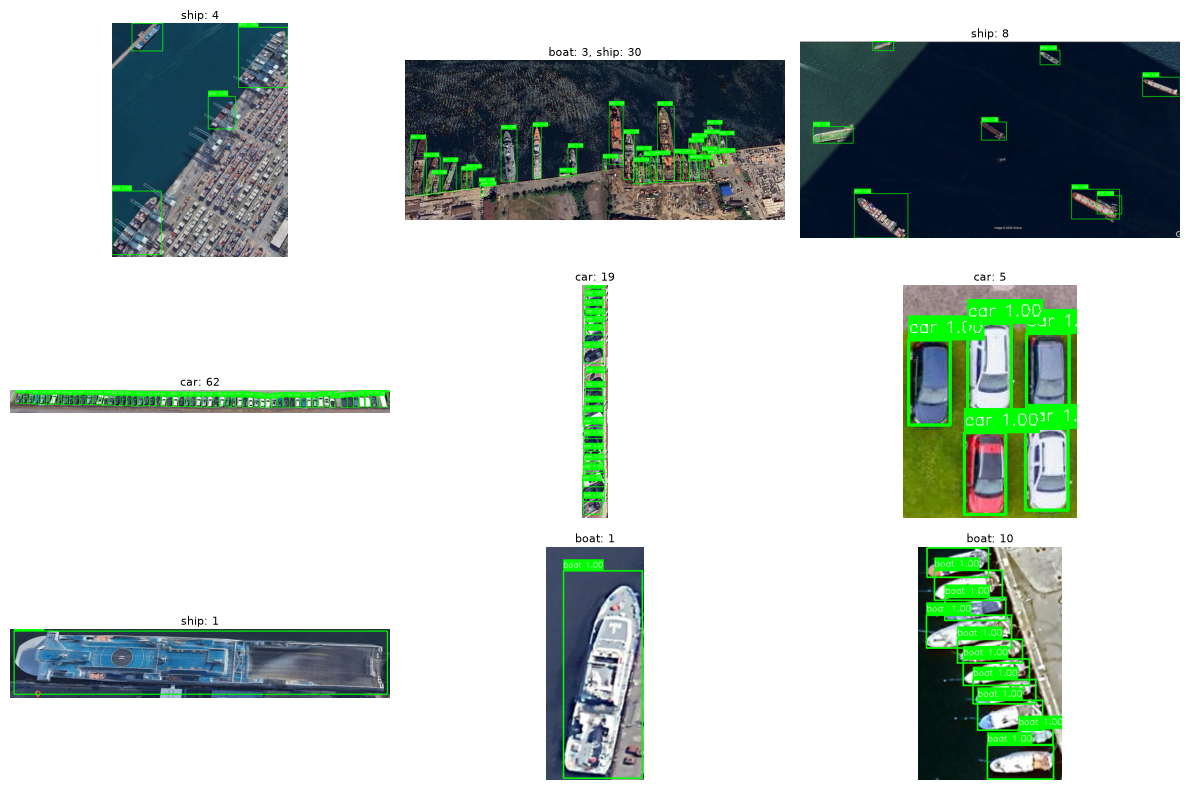

In [7]:
from dataeval_plots import plot

# Show a sample of outlier images (first 9)
if outlier_indices:
    sample = outlier_indices[:9]
    print("Outlier sample: flagged metrics per image:")
    for idx in sample:
        print(f"  Image {idx:>5d}: {', '.join(outlier_grouped[idx])}")
    _ = plot(ds, indices=sample, images_per_row=3, figsize=(12, 8), show_labels=True)

In [8]:
exact_groups = raw.duplicates["items"].get("exact", [])
near_groups = raw.duplicates["items"].get("near", [])

print(f"Exact duplicate groups: {len(exact_groups)}")
print(f"Near  duplicate groups: {len(near_groups)}")

Exact duplicate groups: 0
Near  duplicate groups: 0


In [9]:
# Plot exact duplicate groups (if any)
for i, group in enumerate(exact_groups[:3]):
    indices = group if isinstance(group, list) else group["indices"]
    print(f"\nExact group {i}: indices {indices}")
    _ = plot(ds, indices=indices, images_per_row=len(indices), figsize=(4 * len(indices), 4), show_labels=True)

In [10]:
# Plot near duplicate groups (if any)
for i, group in enumerate(near_groups[:3]):
    indices = group["indices"]
    methods = group.get("methods", [])
    print(f"\nNear group {i}: indices {indices}  (methods: {methods})")
    _ = plot(ds, indices=indices, images_per_row=len(indices), figsize=(4 * len(indices), 4), show_labels=True)

In [11]:
# Define a preparatory pipeline with mode="preparatory"
# Copy the advisory workflow and change name + mode
prep_workflow = advisory_workflow.model_copy(
    update={"name": "skysealand_prep_clean", "mode": "preparatory"},
)

task_prep = DataCleaningTaskConfig(
    name="skysealand-clean-prep",
    workflow="skysealand_prep_clean",
    sources="skysealand_src",
    extractor="bovw_ext",
)

config_prep = PipelineConfig(
    datasets=config.datasets,
    views=config.views,
    sources=config.sources,
    extractors=config.extractors,
    workflows=[advisory_workflow, prep_workflow],
    tasks=[task_prep],
)

result_prep = run_task(task_prep, config_prep, cache_dir=Path("./cache"))

/builds/jatic/aria/dataeval-flow/src/dataeval_flow/workflows/cleaning/workflow.py:268: UserWarning: `height`, `num_annotations` and `width` were binned automatically ('uniform_width') because no bins were declared. The bin count is derived from the data, so it is not stable across samples and the same factor measured twice may not be comparable. Declare cutoffs with continuous_factor_bins={"height": [...]} to control this.
  td = metadata.rows_at(metadata.label_level).select("item_index", "target_index", "class_label")


In [12]:
if not result_prep.success:
    print(f"Workflow failed: {result_prep.errors}")
assert result_prep.success

In [13]:
meta = result_prep.metadata
print(f"Mode: {meta.mode}")
print(f"Flagged for removal : {meta.removed_count}")
print(f"Retained (clean)    : {len(meta.clean_indices)}")

if meta.flagged_indices:
    print(f"\nFirst 20 flagged indices: {meta.flagged_indices[:20]}")

Mode: preparatory
Flagged for removal : 27
Retained (clean)    : 273

First 20 flagged indices: [2, 14, 40, 56, 66, 67, 73, 104, 126, 127, 130, 159, 170, 194, 195, 200, 207, 208, 209, 226]


In [14]:
json_str = result.export(fmt="json")
print(f"JSON output: {len(json_str)} characters")
print(json_str[:500] + "\n...")

JSON output: 81909 characters
{
  "metadata": {
    "version": "1.0",
    "timestamp": "2026-09-19T01:39:24.530215Z",
    "dataset_id": "skysealand_base",
    "label_source": "annotations",
    "model_id": "bovw_ext (bovw)",
    "preprocessor_id": null,
    "selection_id": "sample300",
    "source_descriptions": [
      "skysealand_src (skysealand_base[sample300])"
    ],
    "resolved_config": {
      "sources": [
        {
          "name": "skysealand_src",
          "dataset": "skysealand_base",
          "dataset_config
...
